# Linear fit with constraints - elimination
Author: Aleksander Filip Żarnecki (University of Warsaw)

### (0) Import libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import f
from scipy.stats import norm

### (1) Definition of model

Consider controlled parameter range is [-1,1]

In [2]:
# True functional dependece

def mytrue(x):
    
    val = 0.5 + 0.5*np.cos(x*np.pi + 0.5*np.cos(x*np.pi/2.))

    return val

# Basic functions:  1, x, x^2, x^3 ...

def myfun(x,ifun):

    return np.power(x,ifun)

# Full model

def mymodel(x,par):

    val = np.zeros(x.size)
    
    for ip in range(par.size):
        val+=par[ip]*myfun(x,ip)
        
    return val


### (2) Generate pseudo data to fit

In [3]:
# Considered values of x

xvec = np.linspace(-0.95,0.95,20)

# Measurement precision

svec = np.linspace(0.02,0.03,xvec.size)
s2vec = svec*svec

# Pseudo-data

yvec = np.random.normal(mytrue(xvec),svec)


### (3)  Linear fit without constraint

In [4]:
# Number of model functions to consider 

Nfun = 4

A = np.zeros((Nfun,Nfun))

B = np.zeros(Nfun)

for l in range(Nfun):
    fl = myfun(xvec,l)
    B[l] = np.sum(fl*yvec/s2vec)
    for k in range(Nfun):
        fk = myfun(xvec,k)
        A[l,k] = np.sum(fl*fk/s2vec)


# Inverse of matrix

Cov = np.linalg.inv(A)

# Solution to the problem

par = Cov @ B

# Parameter uncertainties

epar = np.sqrt(np.diagonal(Cov))

print("\n Fit results:\n\n     par         sigma_p\n")

for ip in range(par.size):
    print("  %8.3f  +/- %6.3f " % (par[ip],epar[ip]))

# Calculate correlation matrix

Corr = Cov/np.outer(epar,epar)

np.set_printoptions(precision=3)

print("\n Correlation matrix\n")

for ip in range(par.size):
    print(Corr[ip,:])

# Fitted function

fvec = mymodel(xvec,par) 

# Chi^2 printout

chi2 = np.sum((yvec-fvec)**2/s2vec)

print("\n chi^2 =  %8.3f   chi^2/Ndf = %8.5f " % (chi2,chi2/(xvec.size-Nfun)))

# print("\n  x       y         f(x) ")
# for ix in range(xvec.size):
#     print("%6.3f  %8.5f  %8.5f " % (xvec[ix],yvec[ix],fvec[ix]))


 Fit results:

     par         sigma_p

     0.843  +/-  0.008 
    -0.421  +/-  0.024 
    -1.077  +/-  0.019 
     0.500  +/-  0.037 

 Correlation matrix

[ 1.     0.144 -0.744 -0.157]
[ 0.144  1.    -0.106 -0.914]
[-0.744 -0.106  1.     0.209]
[-0.157 -0.914  0.209  1.   ]

 chi^2 =   358.656   chi^2/Ndf = 22.41601 


### (4)  Linear fit of reduced model

In [5]:
# Number of constraints

Ncon = 2

# Number of parameters in "reduced function" 

Nred = Nfun-Ncon

# reduced model
# Constrains included in the functions formula
# For given number of input parameters, additional terms added to
# take constraints into account (one for even and one for odd terms)

def myred(x,par):

    parsum = np.zeros(2)
    
    for ip in range(par.size):
        parsum[ip%2] -= par[ip]
        
    npar = np.zeros(par.size+2)

    npar[:par.size]=par
    npar[par.size] = parsum[par.size%2]
    npar[par.size+1] = parsum[(par.size+1)%2]
    
    val = np.zeros(x.size)
    
    for ip in range(npar.size):
        val+=npar[ip]*myfun(x,ip)
        
    return val


Ar = np.zeros((Nred,Nred))

Br = np.zeros(Nred)

# additional terms for even and odd powers

lc = np.empty(2, dtype=int)

if Nred%2 == 0 :
    lc[0] = Nred
    lc[1] = Nred+1
else:    
    lc[0] = Nred+1
    lc[1] = Nred

# Calculate arrays including constrain terms

for l in range(Nred):
    fl = myfun(xvec,l) - myfun(xvec,lc[l%2])
    Br[l] = np.sum(fl*yvec/s2vec)
    for k in range(Nred):
        fk = myfun(xvec,k) - myfun(xvec,lc[k%2])
        Ar[l,k] = np.sum(fl*fk/s2vec)


# Inverse of matrix

RCov = np.linalg.inv(Ar)

# Solution to the problem

parr = RCov @ Br

# Parameter uncertainties

eparr = np.sqrt(np.diagonal(RCov))

print("\n Fit results:\n\n     par         sigma_p\n")

for ip in range(parr.size):
    print("  %8.3f  +/- %6.3f " % (parr[ip],eparr[ip]))

# Calculate correlation matrix

RCorr = RCov/np.outer(eparr,eparr)

print("\n Correlation matrix\n")
for ip in range(parr.size):
    print(RCorr[ip,:])

# Fitted function

frvec = myred(xvec,parr) 

# Chi^2 printout

chi2r = np.sum((yvec-frvec)**2/s2vec)

print("\n chi^2 =  %8.3f   chi^2/Ndf = %8.5f " % (chi2r,chi2r/(xvec.size-Nred)))

# print("\n  x       y         f(x) ")
# for ix in range(xvec.size):
#     print("%6.3f  %8.5f  %8.5f " % (xvec[ix],yvec[ix],fvec[ix]))


 Fit results:

     par         sigma_p

     0.786  +/-  0.008 
    -0.307  +/-  0.020 

 Correlation matrix

[1.    0.159]
[0.159 1.   ]

 chi^2 =   740.966   chi^2/Ndf = 41.16477 


In [6]:

dchi = chi2r - chi2

F = (dchi/Ncon)/(chi2/(xvec.size-Nfun))

print("\n F statistics for constraint: %.3f " % (F))

p = f.sf(F,Ncon,xvec.size-Nfun)
sp = norm.isf(p)
print("\n Statistical fluctuation probability p = %.3g (%.2f sigma)" % (p,sp))



 F statistics for constraint: 8.528 

 Statistical fluctuation probability p = 0.00301 (2.75 sigma)


### (5) Draw data and fit

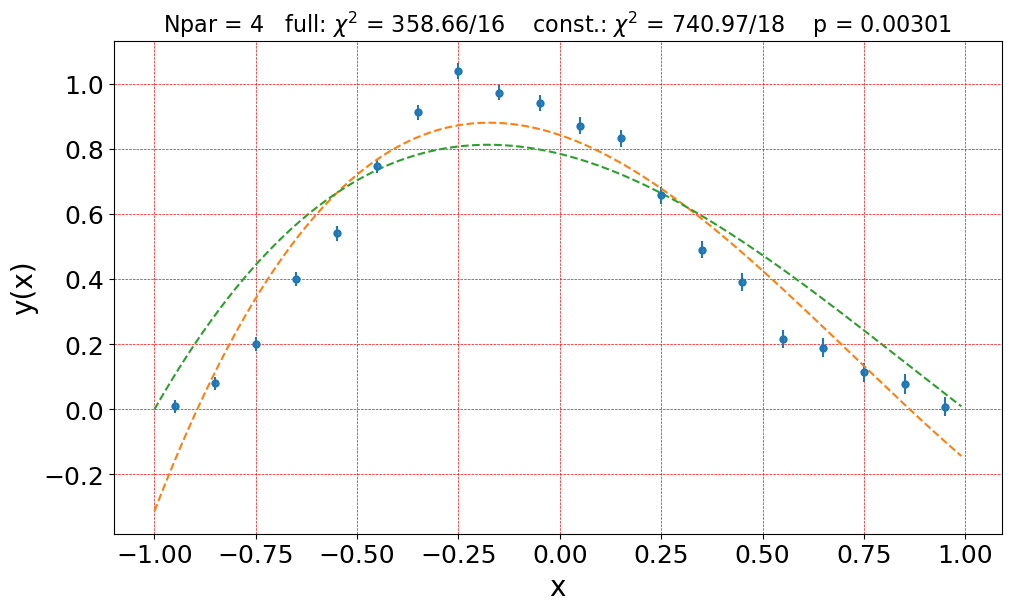

In [7]:
# For more smooth curves on the plot:

xfun = np.arange(-1.,1.,0.01)
fvec = mymodel(xfun,par) 
frvec = myred(xfun,parr) 

plt.figure(figsize=(10, 6),layout='constrained')

plt.errorbar(xvec,yvec,svec, linestyle='none', marker='o', ms=2, mew=4)

plt.plot(xfun,fvec,'--')
plt.plot(xfun,frvec,'--')

plt.title('Npar = {}   full: $\\chi^2$ = {:.2f}/{}    const.: $\\chi^2$ = {:.2f}/{}    p = {:.3g}'.format(Nfun,chi2,xvec.size-Nfun,chi2r,xvec.size-Nred,p),size=16)
    
plt.xlabel('x',size=20)
plt.ylabel('y(x)',size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(which='major', axis='both',color='r', linestyle='--', linewidth=0.5)

fname = '09_reduce_'+str(Nfun)+'.png'
plt.savefig(fname)